### Importando Bibliotecas Básicas

In [104]:

from datetime import datetime, timedelta
import numpy as np
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import pingouin as pg


### Exploraçao

In [3]:
# Criando um caminho universal para que rode em qualquer maquina
pasta_atual = Path.cwd()
pasta_banco = pasta_atual.parent / 'database'

In [ ]:
# Carregando os arquivos e modificando os tipos de dados

contas_df = pd.read_csv(pasta_banco/'account.asc', sep=';', dtype= {'account_id':str, 'district_id': str})
cartoes_df = pd.read_csv(pasta_banco/'card.asc', sep=';', dtype= {'card_id': str,'disp_id':str})
clientes_df = pd.read_csv(pasta_banco/'client.asc', sep=';', dtype= {'client_id':str,'district_id':str, 'birth_number': str})
cliente_conta_df = pd.read_csv(pasta_banco/'disp.asc', sep=';', dtype= {'disp_id':str, 'client_id':str,'account_id':str})
emprestimo_df = pd.read_csv(pasta_banco/'loan.asc', sep=';', dtype = {'loan_id':str,'account_id':str})
ordens_df = pd.read_csv(pasta_banco/'order.asc', sep=';', dtype = {'order_id':str,'account_id':str})
distrito_df = pd.read_csv(pasta_banco/'district.asc', sep=';',na_values=['?'] ,dtype = {'A1':str,'A11':float,'A12':float,'A15':'Int64'})
transacoes_df = pd.read_csv(pasta_banco/'trans.asc', sep=';',dtype={'trans_id' : str,'account_id' : str, 'bank':str}) 


In [ ]:
# 2. Definição do Dicionário de Mapeamento Semântico
# Nota de Qualidade de Dados: 
# A tag 'BAD' denota estritamente um padrão deficiente de qualidade e conformidade (inadimplência estrutural).
mapeamento_status = {
    'A': 'GOOD', # Contrato finalizado, sem pendências
    'B': 'BAD',  # Contrato finalizado, não pago (Padrão deficiente)
    'C': 'GOOD', # Contrato em andamento, regular
    'D': 'BAD'   # Contrato em andamento, em dívida (Padrão deficiente)
}

# 3. Aplicação da regra de negócio criando uma nova coluna analítica
# Preservamos a coluna original 'status' caso seja necessária para auditoria, 
# e criamos 'status_qualidade' para uso no Power BI.
df_loan['status_qualidade'] = df_loan['status'].map(mapeamento_status)

# Verificando a distribuição da nova categorização
print(df_loan['status_qualidade'].value_counts())

In [106]:
emprestimo_df.sample(5)

,id_emprestimo,id_conta,data,valor_total,prazo_meses,valor_parcela,status_pagamento
628,5042,330,1998-07-12,331584,48,6908.0,em andamento_regular
383,6386,6856,1997-04-30,124344,36,3454.0,em andamento_regular
299,6644,8039,1996-10-20,93600,24,3900.0,quitado_regular
554,5491,2545,1998-02-13,428784,48,8933.0,em andamento_regular
532,5930,4616,1998-01-12,66696,24,2779.0,em andamento_regular


In [40]:
# Recolhendo amostras
transacoes_df.sample(10)

,id_transacao,id_conta,data,tipo_movimentacao,modo_operacao,valor_transacao,saldo_apos_transacao,categoria_transacao,banco_parceiro,conta_parceiro
328637,92427,314,1996-06-03,Debito (-),Saque em Dinheiro,2800.0,53670.3,Movimentação Geral,Não se aplica (Interno),0.0
89517,1470583,5011,1994-09-14,Debito (-),Saque em Dinheiro,13500.0,16029.2,Contas de Consumo,Não se aplica (Interno),0.0
34261,437904,1487,1994-01-24,Debito (-),Saque em Dinheiro,180.0,16195.5,Movimentação Geral,Não se aplica (Interno),Não se aplica (Interno)
444171,1194595,4088,1996-12-31,Debito (-),Saque em Dinheiro,14.6,34226.1,Tarifa Bancaria,Não se aplica (Interno),Não se aplica (Interno)
18453,698145,2388,1993-11-05,Credito (+),Transferencia Recebida,3492.0,17760.0,Movimentação Geral,AB,94397276.0
172460,1055500,3609,1995-05-31,Debito (-),Saque em Dinheiro,14.6,42539.3,Tarifa Bancaria,Não se aplica (Interno),Não se aplica (Interno)
13727,3595514,1966,1993-09-30,Credito (+),Sistema / Automático,241.6,59431.5,Juros Recebidos,Não se aplica (Interno),Não se aplica (Interno)
632975,3491701,7721,1997-08-31,Credito (+),Sistema / Automático,163.9,45894.1,Juros Recebidos,Não se aplica (Interno),Não se aplica (Interno)
413432,180581,612,1996-11-08,Debito (-),Transferencia Enviada,1936.0,13278.2,Contas de Consumo,YZ,28562253.0
39677,950846,3241,1994-02-13,Debito (-),Saque em Dinheiro,2160.0,13946.7,Movimentação Geral,Não se aplica (Interno),Não se aplica (Interno)


In [41]:
# Sumario dos dados

transacoes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1056320 entries, 0 to 1056319
Data columns (total 10 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   id_transacao          1056320 non-null  str           
 1   id_conta              1056320 non-null  str           
 2   data                  1056320 non-null  datetime64[us]
 3   tipo_movimentacao     1056320 non-null  str           
 4   modo_operacao         1056320 non-null  str           
 5   valor_transacao       1056320 non-null  float64       
 6   saldo_apos_transacao  1056320 non-null  float64       
 7   categoria_transacao   1056320 non-null  str           
 8   banco_parceiro        1056320 non-null  str           
 9   conta_parceiro        1056320 non-null  object        
dtypes: datetime64[us](1), float64(2), object(1), str(6)
memory usage: 80.6+ MB


In [89]:
# Percentual de nulos
print('Percentual de nulos por coluna:')
print((transacoes_df.isnull().sum() / len(transacoes_df) * 100).round(2))

Percentual de nulos por coluna:
id_transacao            0.0
id_conta                0.0
data                    0.0
tipo_movimentacao       0.0
modo_operacao           0.0
valor_transacao         0.0
saldo_apos_transacao    0.0
categoria_transacao     0.0
banco_parceiro          0.0
conta_parceiro          0.0
dtype: float64


In [90]:
# Verificação de dados unicos para identificaçao de possiveis erros
print(ordens_df['categoria_pagamento'].unique())

<StringArray>
[                 'Despesas Domesticas',
                'Parcela de Emprestimo',
                                    ' ',
                  'Pagamento de Seguro',
 'Financiamento de Veículos e Máquinas']
Length: 5, dtype: str


In [91]:
# Conta quantas linhas possuem o espaço em branco
quantidade_vazios = (ordens_df['categoria_pagamento'] == ' ').sum()
total_linhas = len(ordens_df)
porcentagem = (quantidade_vazios / total_linhas) * 100

print(f"Linhas vazias: {quantidade_vazios} ({porcentagem:.2f}%)")

Linhas vazias: 1379 (21.31%)


In [ ]:
# Substitui o espaço vazio por 'Não Informado'
ordens_df['categoria_pagamento'] = ordens_df['categoria_pagamento'].replace(' ', 'Não Informado')

# Verificação
print(ordens_df['categoria_pagamento'].unique())

<StringArray>
[                 'Despesas Domesticas',
                'Parcela de Emprestimo',
                        'Não Informado',
                  'Pagamento de Seguro',
 'Financiamento de Veículos e Máquinas']
Length: 5, dtype: str


In [ ]:
# Relizando etapa de correçao de erroes em colunas

# Substitui o espaço por uma categoria de "Não Identificado"
transacoes_df['categoria_transacao'] = transacoes_df['categoria_transacao'].replace(' ', 'Não Classificado')



In [ ]:
# Estatisticas descritivas dos dados

def descritivas(data):
  variaveis = data.select_dtypes(include=np.number)
  desc = variaveis.describe().T
  desc["CV"] = desc["std"]/desc["mean"]
  desc["Skew"] = variaveis.skew()
  desc["Kurtosis"] = variaveis.kurt()
  ordered_cols = [
      "count", "mean", "std", "CV",
      "min", "25%", "50%", "75%", "max",
      "Skew", "Kurtosis"
  ]
  desc = desc[ordered_cols]
  return desc.round(2)


In [ ]:
# analise descritiva da coluna CL_FHL (quantidade de filhos por cliente)
descritivas(transacoes_df)

,count,mean,std,CV,min,25%,50%,75%,max,Skew,Kurtosis
valor_transacao,1056320.0,5924.15,9522.74,1.61,0.0,135.9,2100.0,6800.00,87400.0,2.59,7.76
saldo_apos_transacao,1056320.0,38518.33,22117.87,0.57,-41125.7,22402.5,33143.4,49603.62,209637.0,1.23,1.88


##### Coluna "valor_transacao"
- Alta variabilidade: Verificamos que o desvio padrão da coluna está muito alto (cerca de 10.000) em comparação com a sua média (cerca de 6.000). Isso nos mostra que os valores das transações variam drasticamente, o que explica o elevado Coeficiente de Variação de 161%.

- Presença de Outliers: Por mais que a média dos dados seja de 6.000, a nossa mediana (o valor que representa 50% da nossa base) é de apenas 2.100. Essa grande diferença (média muito maior que a mediana) indica claramente que a média está sendo puxada para cima por outliers (transações de valores muito altos).

- Assimetria Positiva: A hipótese acima é confirmada pela métrica de Skewness (Assimetria), que está em cerca de 2.59. Isso comprova que a distribuição dos dados está concentrada em valores menores, com uma cauda longa se estendendo para a direita.

- Valores Extremos: A medida de Kurtosis (Curtose) alta reforça esse cenário, nos explicando que a distribuição possui caudas pesadas. Ou seja, temos uma grande concentração de transações de valor muito baixo (próximas a 0) e, ao mesmo tempo, a presença de transações com valores atipicamente altos.

- Comportamento de Microtransações: Cerca de 1/4 das nossas transações (o 1º Quartil) se concentram em valores de até 140. Do ponto de vista de negócios, isso significa que provavelmente grande parte do nosso volume é composto por tarifas bancárias, pequenos saques, juros ou compras corriqueiras.

##### Coluna "saldo_apos_transacao"
- Uso de Limite/Cheque Especial: Verificamos a presença de saldos negativos, indicando que o banco possui alguma política que permite aos clientes ficarem com a conta negativada. Isso levanta a hipótese de um uso frequente de crédito extra ou cheque especial por parte da base.

- Saúde Financeira e Clientes Alta Renda: A análise permite presumir que boa parte da nossa base de clientes possui uma saúde financeira estável, sem grandes anomalias no dia a dia. Contudo, as métricas de Skew e Kurtosis mostram que a curva de saldo está sendo fortemente puxada para a direita, um indicativo claro de que temos uma parcela de clientes com alto poder aquisitivo (ou grandes empresas) inflando a média geral de saldos.

In [63]:
transacoes_df.sample(5)

,id_transacao,id_conta,data,tipo_movimentacao,modo_operacao,valor_transacao,saldo_apos_transacao,categoria_transacao,banco_parceiro,conta_parceiro
550603,3382304,11231,1997-05-11,Credito (+),Transferencia Recebida,44643.0,107771.0,Movimentação Geral,GH,82542776.0
461925,223316,759,1997-01-12,Credito (+),Deposito em Dinheiro,4900.0,52222.2,Movimentação Geral,Não se aplica (Interno),Não se aplica (Interno)
688095,2912893,9646,1997-11-10,Debito (-),Saque em Dinheiro,6200.0,95323.9,Movimentação Geral,Não se aplica (Interno),0.0
639963,1427139,4863,1997-09-09,Credito (+),Transferencia Recebida,38042.0,84493.2,Movimentação Geral,EF,13974267.0
669157,1128964,3858,1997-10-14,Credito (+),Deposito em Dinheiro,1700.0,28663.1,Movimentação Geral,Não se aplica (Interno),Não se aplica (Interno)


In [65]:
# Analise Descritiva por segmentaçao
transacoes_df.groupby('modo_operacao').apply(descritivas)

count      mean       std  \
modo_operacao                                                               
Deposito em Dinheiro   valor_transacao       156743.0  15429.86  12041.06   
                       saldo_apos_transacao  156743.0  50108.12  28315.65   
Saque com Cartao       valor_transacao         8036.0   2261.12   1213.57   
                       saldo_apos_transacao    8036.0  53271.42  20170.73   
Saque em Dinheiro      valor_transacao       434918.0   5379.20   8848.56   
                       saldo_apos_transacao  434918.0  36995.81  19771.94   
Sistema / Automático   valor_transacao       183114.0    150.02     80.51   
                       saldo_apos_transacao  183114.0  36123.84  19991.91   
Transferencia Enviada  valor_transacao       208283.0   3229.44   2719.02   
                       saldo_apos_transacao  208283.0  35413.97  19505.47   
Transferencia Recebida valor_transacao        65226.0  11981.11  14143.72   
                       saldo_apos_transacao   65226.0  35636.78  24120.74   

                                               CV      min       25%  \
modo_operacao                                                          
Deposito em Dinheiro   valor_transacao       0.78    100.0   5588.00   
                       saldo_apos_transacao  0.57 -25568.6  29326.15   
Saque com Cartao       valor_transacao       0.54    100.0   1300.00   
                       saldo_apos_transacao  0.38 -11711.7  38813.43   
Saque em Dinheiro      valor_transacao       1.64      0.0     14.60   
                       saldo_apos_transacao  0.53 -41125.7  22569.43   
Sistema / Automático   valor_transacao       0.54      0.0     89.70   
                       saldo_apos_transacao  0.55 -16390.2  21477.72   
Transferencia Enviada  valor_transacao       0.84      1.0   1152.00   
                       saldo_apos_transacao  0.55 -17030.4  20599.10   
Transferencia Recebida valor_transacao       1.18   2900.0   3849.00   
                       saldo_apos_transacao  0.68 -31178.7  20144.12   

                                                  50%       75%       max  \
modo_operacao                                                               
Deposito em Dinheiro   valor_transacao       13564.00  22184.00   49999.0   
                       saldo_apos_transacao  45465.50  65488.45  209637.0   
Saque com Cartao       valor_transacao        2200.00   3000.00    8000.0   
                       saldo_apos_transacao  51031.60  66046.17  155592.5   
Saque em Dinheiro      valor_transacao        1680.00   6800.00   87400.0   
                       saldo_apos_transacao  32752.80  47092.08  174283.3   
Sistema / Automático   valor_transacao         133.00    195.60     565.5   
                       saldo_apos_transacao  31319.85  46002.65  158959.2   
Transferencia Enviada  valor_transacao        2536.00   4588.50   14882.0   
                       saldo_apos_transacao  30387.40  46180.40  155219.5   
Transferencia Recebida valor_transacao        5550.00  12710.00   74812.0   
                       saldo_apos_transacao  26792.75  42112.60  165654.3   

                                             Skew  Kurtosis  
modo_operacao                                                
Deposito em Dinheiro   valor_transacao       0.83      0.11  
                       saldo_apos_transacao  0.85      0.74  
Saque com Cartao       valor_transacao       0.95      2.25  
                       saldo_apos_transacao  0.49      0.13  
Saque em Dinheiro      valor_transacao       2.81     10.20  
                       saldo_apos_transacao  1.09      1.45  
Sistema / Automático   valor_transacao       0.90      0.62  
                       saldo_apos_transacao  1.19      1.50  
Transferencia Enviada  valor_transacao       1.20      1.35  
                       saldo_apos_transacao  1.10      1.04  
Transferencia Recebida valor_transacao       1.93      3.00  
                       saldo_apos_transacao  1.64      2.34

### Tabela "transacoes_df
#### Coluna "tipo_movimentacao"

##### Contagem
- Temos cerca de 651 mil transações de Débito contra 405 mil de Crédito, o que é um alto indicativo que uma boa parcela dos nossos clientes mais gastam do que recebem, oque representa que temos algum uso de cheque especial dentro da nossa base

##### Media e Mediana
- Foi identificado que temos uma grande diferença entre a media e a mediana, pelo menos 50% dos nossos clientes, gastam ate 2.200 reais, a media não reflete a mesma realida, pois muito provavelmente, temos outliers puxando esta media para cima

##### Coeficiente de Variação e Desvio Padrao
- Valores acima de 1 indicam altissima dispersao, o que nos leva a considerar que dentro da nossa base de dados existe uma variaçao de tipos de clientes (baixa renda e alta renda) ou (contas PJ misturados com PF)

- **Possivel Ação:** clusterizar os clientes iremos usar **Machine Learning**

##### Min / Max e Quartis
- Foi possivel verificar que temos valores negativos nas duas colunas "valor_transacao" e "saldo_apos_transacao" respectivamente de -31.000 e -41.000, oque diz que nossos clientes estao usando cheque especial ou limite de credito

##### Skew / Kurtosis
- Nossos dados nao Assimetricos (Skew) ou seja, temos uma concentraçao massiva de valores pequenos e uma cauda longa de valores grandes
- Geralmente, para uma distribuiçao normal de Kurtosis, se espera valores de ate 3, mas no caso da coluna "tipo_movimento" Debito para a coluna ""valor_transacao", tivemos um valor de 15.68, oque nos diz que ha anomalias ou comportamentos atipicos dentro da nossa base de dados.
    - Podemos levantar algumas poucas hipoteses, pode ser fraude ou compra de maquinarios por empresas (PJ)
    - **Ação:** Isolar estes dados e investigalos


------------------------------------------------------------------------------------------------------------

#### Coluna "modo_operacao"

##### Contagem
- Podemos identificar que dentro da coluna "modo_operacao" temos cerca de 41% dos nossos clientes dentro da operação **Saque em Dinheiro** e cerca de 19% dentro da operação **Transferencia Enviada**

##### Media e Mediana
- Foi identificado que temos outlier

##### Coeficiente de Variação e Desvio Padrao
- 

##### Min / Max e Quartis
- 

##### Skew / Kurtosis
- 

In [ ]:
# Linhas duplicadas
transacoes_df.duplicated().sum()

np.int64(0)

### Tratamento de Datas

In [16]:
# Tratamento de datas na tabela de transacoes_df
# transformamos o número inteiro em texto (string)
transacoes_df['date'] = transacoes_df['date'].astype(str)

# convertendo para datetime usando o formato YYMMDD (padrão do banco Berka, conforme documentacao deste dataset)
transacoes_df['date'] = pd.to_datetime(
    transacoes_df['date'],
    format='%y%m%d',
    errors='coerce'
)


# ____________________________________________________________________________________

# Tratamento de datas na tabela de emprestimo_df
emprestimo_df['date'] = emprestimo_df['date'].astype(str)

emprestimo_df['date'] = pd.to_datetime(
    emprestimo_df['date'],
    format='%y%m%d',
    errors='coerce'
)

# ____________________________________________________________________________________

# Tratamento de datas na tabela de cartoes_df
cartoes_df['issued'] = cartoes_df['issued'].astype(str).str[:6]

cartoes_df['issued'] = pd.to_datetime(
    cartoes_df['issued'],
    format='%y%m%d',
    errors='coerce'
)
# ____________________________________________________________________________________

# Tratamento de datas na tabela de contas_df
contas_df['date'] = contas_df['date'].astype(str).str[:6]
contas_df['date'] = pd.to_datetime(
    contas_df['date'],
    format= '%y%m%d',
    errors='coerce'
)


# verificação rápida para garantir que funcionou e ver o real alcance dos dados
print(f"Data Mínima das Transações: {contas_df['date'].min()}")
print(f"Data Máxima das Transações: {contas_df['date'].max()}")

Data Mínima das Transações: 1993-01-01 00:00:00
Data Máxima das Transações: 1997-12-29 00:00:00


In [18]:
# Tratamento de datas na tabela de client_df

clientes_df['birth_number'] = clientes_df['birth_number'].str.zfill(6)

# criando variaveis para que recebam o dia,ano,mes fatiado para facilitar a analise e tratamento
# e alterando o tipo de dados para realizar 

ano = clientes_df['birth_number'].str[:2]
mes = clientes_df['birth_number'].str[2:4].astype(int)
dia = clientes_df['birth_number'].str[4:]

# iremos criar a coluna o genero dos clientes com base no mes

clientes_df['gender'] = np.where(mes > 50, 'F', 'M')

# arrumando o mes para que ele retorne se somente for mulher

mes_limpo = np.where(mes > 50, mes - 50, mes)

# Volta o mês para texto com 2 dígitos (para que o mês 8 volte a ser '08')

mes_limpo_str = pd.Series(mes_limpo).astype(str).str.zfill(2)

# remontando a data e convertendo para datetime e forçando a inserçao do seculo, estipulando que os clientes nasceram no seculo 19

clientes_df['birth_date'] = pd.to_datetime('19' + ano + mes_limpo_str + dia, format='%Y%m%d')

# coluna original birth_date apagada 
clientes_df = clientes_df.drop(columns=['birth_number'])

### Criando dimCalendario

In [19]:

# identificando o ano inial e final para criar a tabela dim calendario
ano_inicio = transacoes_df['date'].min().year
ano_fim = transacoes_df['date'].max().year

# 2. Definir o intervalo completo (01/Jan do primeiro ano até 31/Dez do último ano)
data_inicio_completa = f'{ano_inicio}-01-01'
data_fim_completa = f'{ano_fim}-12-31'

# 3. Criar a sequência contínua de dias
datas_calendario = pd.date_range(start=data_inicio_completa, end=data_fim_completa)

# 4. Criar o DataFrame da dCalendario
dimCalendario = pd.DataFrame({'date': datas_calendario})

# 5. Extrair as colunas derivadas de forma segura (usando a própria dimCalendario)
dimCalendario['date_year'] = dimCalendario['date'].dt.year
dimCalendario['date_month'] = dimCalendario['date'].dt.month
dimCalendario['date_quarter'] = dimCalendario['date'].dt.quarter
dimCalendario['date_year_month'] = dimCalendario['date'].dt.strftime('%Y-%m')
dimCalendario['date_week'] = dimCalendario['date'].dt.isocalendar().week
dimCalendario['date_day'] = dimCalendario['date'].dt.day
dimCalendario['date_day_name'] = dimCalendario['date'].dt.day_name()

# Visualizar o resultado final do calendário
dimCalendario

,date,date_year,date_month,date_quarter,date_year_month,date_week,date_day,date_day_name
0,1993-01-01,1993,1,1,1993-01,53,1,Friday
1,1993-01-02,1993,1,1,1993-01,53,2,Saturday
2,1993-01-03,1993,1,1,1993-01,53,3,Sunday
3,1993-01-04,1993,1,1,1993-01,1,4,Monday
4,1993-01-05,1993,1,1,1993-01,1,5,Tuesday
...,...,...,...,...,...,...,...,...
2186,1998-12-27,1998,12,4,1998-12,52,27,Sunday
2187,1998-12-28,1998,12,4,1998-12,53,28,Monday
2188,1998-12-29,1998,12,4,1998-12,53,29,Tuesday
2189,1998-12-30,1998,12,4,1998-12,53,30,Wednesday


### Correcao de Inconsistencias e traduçao de linhas e colunas

In [20]:
# tabela contas_df

contas_df = contas_df.rename(columns={
    'account_id': 'id_conta',
    'district_id': 'id_distrito',
    'date': 'data',
    'frequency': 'frequencia'
})

ajustar = {
    'POPLATEK MESICNE': 'emissao_mensal',
    'POPLATEK PO OBRATU': 'emissao_semanal',
    'POPLATEK TYDNE': 'emissao_pos_transacao'
}


contas_df['frequencia'] = contas_df['frequencia'].replace(ajustar)
contas_df.head(2)

,id_conta,id_distrito,frequencia,data
0,576,55,emissao_mensal,1993-01-01
1,3818,74,emissao_mensal,1993-01-01


In [21]:
# tabela contas_df

cartoes_df = cartoes_df.rename(columns={
    'card_id': 'id_cartao',
    'disp_id': 'id_disp',
    'type': 'tipo_cartao',
    'issued': 'data'
})


cartoes_df.sample(10)

,id_cartao,id_disp,tipo_cartao,data
346,259,1610,classic,1997-09-05
879,573,3638,classic,1998-12-23
774,751,4941,junior,1998-10-15
423,569,3616,classic,1997-12-12
442,434,2739,classic,1997-12-30
175,1014,9452,classic,1996-11-02
566,756,5012,classic,1998-05-18
784,769,5224,classic,1998-10-20
74,504,3230,junior,1995-11-06
764,366,2335,classic,1998-10-09


In [22]:
# tabela clientes_df

clientes_df = clientes_df.rename(columns={
    'client_id': 'id_cliente',
    'district_id': 'id_distrito',
    'gender': 'genero',
    'birth_date': 'data_nascimento'
})




clientes_df.sample(10)

,id_cliente,id_distrito,genero,data_nascimento
1480,1568,50,F,1927-06-29
4661,5224,29,M,1949-07-24
1304,1373,74,F,1975-02-08
5308,13171,19,F,1950-06-26
3748,3960,8,M,1964-01-06
1379,1458,67,M,1938-04-08
1117,1173,54,M,1922-06-02
612,643,1,F,1949-06-13
4976,8666,7,F,1971-08-28
3634,3840,50,F,1933-06-12


In [23]:
# tabela cliente_conta_df

cliente_conta_df = cliente_conta_df.rename(columns={
    'disp_id	': 'id_disp',
    'client_id': 'id_cliente',
    'account_id': 'id_conta',
    'type': 'tipo_acesso'
})

ajustar = {
    'OWNER': 'proprietario',
    'DISPONENT': 'usuario'
}

cliente_conta_df['tipo_acesso'] = cliente_conta_df['tipo_acesso'].replace(ajustar)
cliente_conta_df.sample(10)


,disp_id,id_cliente,id_conta,tipo_acesso
1972,2087,2087,1721,proprietario
1346,1422,1422,1181,proprietario
2787,2945,2945,2439,proprietario
1691,1794,1794,1481,proprietario
1851,1962,1962,1618,proprietario
657,689,689,574,proprietario
4406,4661,4661,3867,proprietario
139,149,149,124,proprietario
4675,5263,5263,4368,proprietario
4256,4501,4501,3731,proprietario


In [24]:
# tabela emprestimo_df

emprestimo_df = emprestimo_df.rename(columns={
    'loan_id': 'id_emprestimo',
    'account_id': 'id_conta',
    'date': 'data',
    'amount': 'valor_total',
    'duration': 'prazo_meses',
    'payments': 'valor_parcela',
    'status': 'status_pagamento'
})

ajustar = {
    'A': 'quitado_regular',
    'B': 'inadimplente',
    'C': 'em andamento_regular',
    'D': 'em andamento_crédito_defectivo'
}


emprestimo_df['status_pagamento'] = emprestimo_df['status_pagamento'].replace(ajustar)
emprestimo_df.sample(10)

,id_emprestimo,id_conta,data,valor_total,prazo_meses,valor_parcela,status_pagamento
651,7091,10243,1998-09-22,113436,36,3151.0,em andamento_regular
385,5758,3859,1997-05-02,307200,60,5120.0,em andamento_crédito_defectivo
230,6816,9017,1996-03-26,100224,48,2088.0,em andamento_crédito_defectivo
87,7061,10105,1994-08-27,121896,24,5079.0,quitado_regular
193,5449,2343,1995-11-04,99336,24,4139.0,quitado_regular
245,5706,3608,1996-05-24,161496,36,4486.0,em andamento_regular
216,7263,11138,1996-01-19,89880,24,3745.0,quitado_regular
641,5520,2699,1998-08-30,231168,48,4816.0,em andamento_regular
15,6456,7123,1993-12-09,47016,12,3918.0,quitado_regular
257,6667,8127,1996-07-15,155880,24,6495.0,quitado_regular


In [25]:
# tabela ordens_df

ordens_df = ordens_df.rename(columns={
    'order_id': 'id_ordem',
    'account_id': 'id_conta',
    'bank_to': 'banco_destino',
    'account_to': 'conta_destino',
    'amount': 'valor_debito',
    'k_symbol': 'categoria_pagamento'
})

ajustar = {
    'SIPO': 'Despesas Domesticas',
    'UVER': 'Parcela de Emprestimo',
    'POJISTNE': 'Pagamento de Seguro',
    'LEASING': 'Financiamento de Veículos e Máquinas'
}


ordens_df['categoria_pagamento'] = ordens_df['categoria_pagamento'].replace(ajustar)
ordens_df.sample(10)

,id_ordem,id_conta,banco_destino,conta_destino,valor_debito,categoria_pagamento
3025,32754,2280,QR,5897534,6841.0,Despesas Domesticas
2546,32207,1916,QR,71571534,4269.0,Despesas Domesticas
1489,31035,1120,KL,15175223,1195.0,Despesas Domesticas
5549,36730,4981,GH,9506047,3736.0,Parcela de Emprestimo
4563,34448,3413,IJ,9298742,242.0,
1631,31206,1235,QR,36736953,1843.0,Despesas Domesticas
6139,42966,9153,ST,27339548,1451.0,Parcela de Emprestimo
794,30260,579,CD,61798560,1065.0,
976,30475,732,GH,38898217,5129.0,Despesas Domesticas
5409,35765,4330,OP,83009093,1786.0,


In [26]:
# tabela distrito_df

distrito_df = distrito_df.rename(columns={
    'A1': 'id_distrito',
    'A2': 'nome_distrito',
    'A3': 'regiao',
    'A4': 'num_habitantes',
    'A5': 'municipios_ate_499_hab',
    'A6': 'municipios_500_1999_hab',
    'A7': 'municipios_2000_9999_hab',
    'A8': 'municipios_mais_10000_hab',
    'A9': 'num_cidades',
    'A10': 'proporcao_populacao_urbana',
    'A11': 'salario_medio',
    'A12': 'taxa_desemprego_95',
    'A13': 'taxa_desemprego_96',
    'A14': 'num_empreendedores_por_1000_hab',
    'A15': 'crimes_cometidos_95',
    'A16': 'crimes_cometidos_96'
})


distrito_df['regiao'] = distrito_df['regiao'].str.capitalize()

distrito_df.sample(10)

,id_distrito,nome_distrito,regiao,num_habitantes,municipios_ate_499_hab,municipios_500_1999_hab,municipios_2000_9999_hab,municipios_mais_10000_hab,num_cidades,proporcao_populacao_urbana,salario_medio,taxa_desemprego_95,taxa_desemprego_96,num_empreendedores_por_1000_hab,crimes_cometidos_95,crimes_cometidos_96
23,24,Karlovy Vary,West bohemia,122603,25,21,6,2,8,80.0,8991.0,1.39,2.01,128,5198,5273
67,68,Frydek - Mistek,North moravia,228848,15,40,18,2,6,57.2,9893.0,4.09,4.72,96,5623,5887
13,14,Ceske Budejovice,South bohemia,177686,69,27,10,1,9,74.8,10045.0,1.42,1.71,135,6604,6295
42,43,Hradec Kralove,East bohemia,161854,73,21,6,1,6,76.3,9425.0,1.72,2.50,125,4085,3891
76,77,Vsetin,North moravia,148545,8,35,12,3,4,53.5,8909.0,4.01,5.56,113,3460,3590
50,51,Trutnov,East bohemia,121947,37,28,7,3,11,70.5,8541.0,2.51,2.97,131,3496,3839
28,29,Rokycany,West bohemia,45714,52,10,5,1,6,55.6,8843.0,2.82,3.60,113,818,888
3,4,Kladno,Central bohemia,149893,63,29,6,2,6,67.4,9753.0,4.64,5.05,109,5244,5892
64,65,Znojmo,South moravia,114200,101,41,4,1,4,43.7,8403.0,5.74,5.72,105,2157,2718
6,7,Melnik,Central bohemia,94725,38,28,1,3,6,63.4,9920.0,2.26,2.87,130,4289,4846


In [27]:
# tabela ordens_df

transacoes_df = transacoes_df.rename(columns={
    'trans_id': 'id_transacao',
    'account_id': 'id_conta',
    'date': 'data',
    'type': 'tipo_movimentacao',
    'operation': 'modo_operacao',
    'amount': 'valor_transacao',
    'balance': 'saldo_apos_transacao',
    'k_symbol': 'categoria_transacao',
    'bank': 'banco_parceiro',
    'account': 'conta_parceiro'
})

tipo_mov = {
    'PRIJEM': 'Credito (+)',
    'VYDAJ': 'Debito (-)',
    'VYBER': 'Debito (-)'
}


tipo_ope = {
    'VKLAD': 'Deposito em Dinheiro',
    'PREVOD Z UCTU': 'Transferencia Recebida',
    'VYBER': 'Saque em Dinheiro',
    'PREVOD NA UCET': 'Transferencia Enviada',
    'VYBER KARTOU': 'Saque com Cartao'
}

tipo_trans ={
    'POJISTNE': 'Pagamento de Seguro',
    'SLUZBY': 'Tarifa Bancaria',
    'UROK': 'Juros Recebidos',
    'SANKC. UROK': 'Juros de Multa',
    'SIPO': 'Contas de Consumo',
    'DUCHOD': 'Aposentadoria / Pensao',
    'UVER': 'Parcela de Emprestimo'
}




transacoes_df['tipo_movimentacao'] = transacoes_df['tipo_movimentacao'].replace(tipo_mov)
transacoes_df['modo_operacao'] = transacoes_df['modo_operacao'].replace(tipo_ope)
transacoes_df['categoria_transacao'] = transacoes_df['categoria_transacao'].replace(tipo_trans)
transacoes_df.sample(2)

,id_transacao,id_conta,data,tipo_movimentacao,modo_operacao,valor_transacao,saldo_apos_transacao,categoria_transacao,banco_parceiro,conta_parceiro
103128,2747266,9093,1994-11-07,Debito (-),Transferencia Enviada,2617.0,47282.7,,QR,62233042.0
6938,1450020,4937,1993-07-30,Credito (+),Deposito em Dinheiro,46108.0,69242.3,NaN,NaN,NaN


In [72]:
# Percentual de nulos — mais útil em bases grandes
# len(df) = número total de linhas
print('Percentual de nulos por coluna:')
print((transacoes_df.isnull().sum() / len(transacoes_df) * 100).round(2))

Percentual de nulos por coluna:
id_transacao            0.0
id_conta                0.0
data                    0.0
tipo_movimentacao       0.0
modo_operacao           0.0
valor_transacao         0.0
saldo_apos_transacao    0.0
categoria_transacao     0.0
banco_parceiro          0.0
conta_parceiro          0.0
dtype: float64


### Tratamento de Missing Values

In [29]:
# Definindo valores substitutos que fazem sentido para o negócio do banco

# tabela transacoes_df

valores_substitutos = {
    'modo_operacao': 'Sistema / Automático',
    'categoria_transacao': 'Movimentação Geral',
    'banco_parceiro': 'Não se aplica (Interno)',
    'conta_parceiro': 'Não se aplica (Interno)'
}

# Aplicando nosso dicionario para preencher Missing Values
transacoes_df = transacoes_df.fillna(value=valores_substitutos)

In [30]:
# Percentual de nulos — mais útil em bases grandes  (POS PROCESSAMENTO DOS NULOS)

print('Percentual de nulos por coluna:')
print((transacoes_df.isnull().sum() / len(transacoes_df) * 100).round(2))

Percentual de nulos por coluna:
id_transacao            0.0
id_conta                0.0
data                    0.0
tipo_movimentacao       0.0
modo_operacao           0.0
valor_transacao         0.0
saldo_apos_transacao    0.0
categoria_transacao     0.0
banco_parceiro          0.0
conta_parceiro          0.0
dtype: float64


In [ ]:
# Iremos preencher os Missing Values com modo de Imputaçao Estratificada preenchendo a taxa de desemprego com a mediana da própria região daquele distrito

# 1. Transformamos temporariamente para float para aceitar as medianas do groupby
distrito_df['crimes_cometidos_95'] = distrito_df['crimes_cometidos_95'].astype(float)

# 2. Agora aplicamos a imputação estratificada (vai rodar sem reclamar)
distrito_df['crimes_cometidos_95'] = distrito_df['crimes_cometidos_95'].fillna(
    distrito_df.groupby('regiao')['crimes_cometidos_95'].transform('median')
)

# 3. Como não existe "meio crime", limpamos a coluna transformando-a em inteiro puro
distrito_df['crimes_cometidos_95'] = distrito_df['crimes_cometidos_95'].astype(int)

# Aplicando a imputação estratificada na taxa de desemprego de 95
distrito_df['taxa_desemprego_95'] = distrito_df['taxa_desemprego_95'].fillna(
    distrito_df.groupby('regiao')['taxa_desemprego_95'].transform('median')
)


In [98]:
distrito_df.sample(5)

,id_distrito,nome_distrito,regiao,num_habitantes,municipios_ate_499_hab,municipios_500_1999_hab,municipios_2000_9999_hab,municipios_mais_10000_hab,num_cidades,proporcao_populacao_urbana,salario_medio,taxa_desemprego_95,taxa_desemprego_96,num_empreendedores_por_1000_hab,crimes_cometidos_95,crimes_cometidos_96
61,62,Uherske Hradiste,South moravia,145688,22,41,13,2,5,40.7,8544.0,1.29,1.86,109,2719,2906
21,22,Domazlice,West bohemia,58400,65,16,4,1,6,52.4,8620.0,1.10,1.25,100,1089,1117
73,74,Ostrava - mesto,North moravia,323870,0,0,0,1,1,100.0,10673.0,4.75,5.44,100,18782,18347
74,75,Prerov,North moravia,138032,67,30,4,2,5,64.6,8819.0,5.38,5.66,99,4063,4505
36,37,Litomerice,North bohemia,114006,71,26,6,2,9,62.3,9065.0,4.46,5.39,123,4147,4166


### Tratamento de Outliers

In [32]:
# Imputaçao Estratificada

transacoes_df_copy = transacoes_df


# Identificacao de Outliers com IQR

outliers = {}

# Filtragem por IQR

for col in transacoes_df_copy.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = transacoes_df_copy[col].quantile(0.25)
    Q3 = transacoes_df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    filtro = (transacoes_df_copy[col] < limite_inferior) | (transacoes_df_copy[col] > limite_superior)
    count = filtro.sum()

    # Contagem de Outliers por coluna

    if count > 0:
        menor_valor = transacoes_df_copy.loc[filtro, col].min()
        maior_valor = transacoes_df_copy.loc[filtro, col].max()
    else:
        maior_valor = None
        menor_valor = None
    
    # Construindo um dataframe com os Outliers encontrados

    outliers[col] = {
        'Contagem de Outliers': count,
        '% de Outliers': ((count / len(transacoes_df_copy)) * 100).round(3),
        'Limite Inferior': limite_inferior.round(3),
        'Limite Superior': limite_superior.round(3),
        'Maior outlier': maior_valor,
        'Menor outlier': menor_valor
    }


outlier_df = pd.DataFrame.from_dict(outliers, orient='index')
outlier_df.head()

,Contagem de Outliers,% de Outliers,Limite Inferior,Limite Superior,Maior outlier,Menor outlier
valor_transacao,120215,11.381,-9860.250,16796.150,87400.0,16797.0
saldo_apos_transacao,34806,3.295,-18399.188,90405.312,209637.0,-41125.7


#### Motivo da Decisão

Durante a etapa de Análise Exploratória de Dados (EDA) na tabela de transações, identificamos uma alta volatilidade nos dados. Aplicamos o cálculo de Intervalo Interquartil (IQR) para mapear valores discrepantes e descobrimos que:

- Cerca de 11,38% da base da coluna valor_transacao (mais de 120 mil registros) está classificada matematicamente como outlier.

- Cerca de 3,29% da coluna saldo_apos_transacao (quase 35 mil registros) também se enquadram como outliers, incluindo saldos extremamente negativos.


Decidimos utilizar a Clusterização baseada em Regras de Negócio, aproveitando os limites matemáticos exatos que já havíamos calculado através do IQR.

Em vez de alterar ou excluir os dados, isolamos a base em dois DataFrames distintos, usando o Limite Superior de R$ 16.796,15 como linha de corte:

- Cluster Varejo Comum: Contém 88% das transações (valores até R$ 16.796). Representa o comportamento padrão do correntista pessoa física.

- Cluster Alta Renda / PJ: Contém os 11% de outliers (valores acima de R$ 16.796). Representa o comportamento de grandes movimentadores.

In [ ]:
# Clusterização
limite_sup_valor = 16796.150

# CLUSTER A: Varejo Comum (Dados normais, dentro do limite)
df_varejo = transacoes_df[transacoes_df['valor_transacao'] <= limite_sup_valor].copy()

# CLUSTER B: Alta Renda / PJ (Outliers, acima do limite)
df_alta_renda = transacoes_df[transacoes_df['valor_transacao'] > limite_sup_valor].copy()

print(f"Tamanho do Varejo (Cluster A): {len(df_varejo)} transações")
print(f"Tamanho da Alta Renda (Cluster B): {len(df_alta_renda)} transações")

df_alta_renda

Tamanho do Varejo (Cluster A): 936105 transações
Tamanho da Alta Renda (Cluster B): 120215 transações


,id_transacao,id_conta,data,tipo_movimentacao,modo_operacao,valor_transacao,saldo_apos_transacao,categoria_transacao,banco_parceiro,conta_parceiro
42,1117248,3818,1993-01-09,Credito (+),Deposito em Dinheiro,17366.0,17966.0,Movimentação Geral,Não se aplica (Interno),Não se aplica (Interno)
58,207265,704,1993-01-12,Credito (+),Deposito em Dinheiro,17477.0,18477.0,Movimentação Geral,Não se aplica (Interno),Não se aplica (Interno)
73,1548750,5270,1993-01-14,Credito (+),Transferencia Recebida,44749.0,45549.0,Movimentação Geral,IJ,80269753.0
76,621775,2122,1993-01-15,Credito (+),Deposito em Dinheiro,46552.0,46852.0,Movimentação Geral,Não se aplica (Interno),Não se aplica (Interno)
80,1027726,3510,1993-01-17,Credito (+),Deposito em Dinheiro,23323.0,23823.0,Movimentação Geral,Não se aplica (Interno),Não se aplica (Interno)
...,...,...,...,...,...,...,...,...,...,...
1051802,1009071,3446,1998-12-30,Debito (-),Saque em Dinheiro,25500.0,95357.0,Movimentação Geral,Não se aplica (Interno),Não se aplica (Interno)
1051803,2520380,8316,1998-12-30,Credito (+),Deposito em Dinheiro,36712.0,92753.3,Movimentação Geral,Não se aplica (Interno),Não se aplica (Interno)
1051804,2520673,8316,1998-12-30,Debito (-),Saque em Dinheiro,21200.0,121376.3,Movimentação Geral,Não se aplica (Interno),Não se aplica (Interno)
1051806,2520387,8316,1998-12-30,Credito (+),Deposito em Dinheiro,49823.0,142576.3,Movimentação Geral,Não se aplica (Interno),Não se aplica (Interno)


In [97]:
# Indentificando a distribuiçao de Missing Values

(distrito_df.isnull().sum()*100/distrito_df.index.size).round(2).sort_values(ascending=False)

id_distrito                        0.0
nome_distrito                      0.0
regiao                             0.0
num_habitantes                     0.0
municipios_ate_499_hab             0.0
municipios_500_1999_hab            0.0
municipios_2000_9999_hab           0.0
municipios_mais_10000_hab          0.0
num_cidades                        0.0
proporcao_populacao_urbana         0.0
salario_medio                      0.0
taxa_desemprego_95                 0.0
taxa_desemprego_96                 0.0
num_empreendedores_por_1000_hab    0.0
crimes_cometidos_95                0.0
crimes_cometidos_96                0.0
dtype: float64

In [73]:
#Calculando a Skewness

import scipy.stats as stats

g1 = stats.skew(transacoes_df_copy['valor_transacao'])

print(f'A skewness da valor_transacao é {g1}')

A skewness da valor_transacao é 2.590640386812571


In [74]:
#Função de análise gráfica

def comparar_variavel(dados, var_quantitativa, var_categorica):

    plt.figure(figsize=(14, 5))

    # Boxplot
    plt.subplot(1, 2, 1)
    sns.boxplot(data=dados, x=var_categorica, y=var_quantitativa)
    plt.title(f'Boxplot de {var_quantitativa} por {var_categorica}')
    plt.xticks()

    # KDE Plot
    plt.subplot(1, 2, 2)

    for categoria in dados[var_categorica].unique():
        subset = dados[dados[var_categorica] == categoria]
        sns.kdeplot(subset[var_quantitativa], label=categoria, fill=True, alpha=0.3)

    plt.title(f'Distribuição de {var_quantitativa} por {var_categorica}')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [77]:
# Recolhendo amostras
transacoes_df.sample(5)

,id_transacao,id_conta,data,tipo_movimentacao,modo_operacao,valor_transacao,saldo_apos_transacao,categoria_transacao,banco_parceiro,conta_parceiro
207042,916272,3124,1995-09-08,Credito (+),Deposito em Dinheiro,15032.0,43554.0,Movimentação Geral,Não se aplica (Interno),Não se aplica (Interno)
154928,3402836,11295,1995-04-07,Debito (-),Saque em Dinheiro,2500.0,29498.7,Não Classificado,Não se aplica (Interno),0.0
100034,259952,890,1994-10-31,Debito (-),Saque em Dinheiro,2280.0,22053.8,Movimentação Geral,Não se aplica (Interno),Não se aplica (Interno)
665788,695044,2377,1997-10-12,Debito (-),Transferencia Enviada,1652.0,14690.9,Não Classificado,UV,10629874.0
1031210,841545,2864,1998-11-30,Debito (-),Saque em Dinheiro,14.6,51658.2,Tarifa Bancaria,Não se aplica (Interno),Não se aplica (Interno)


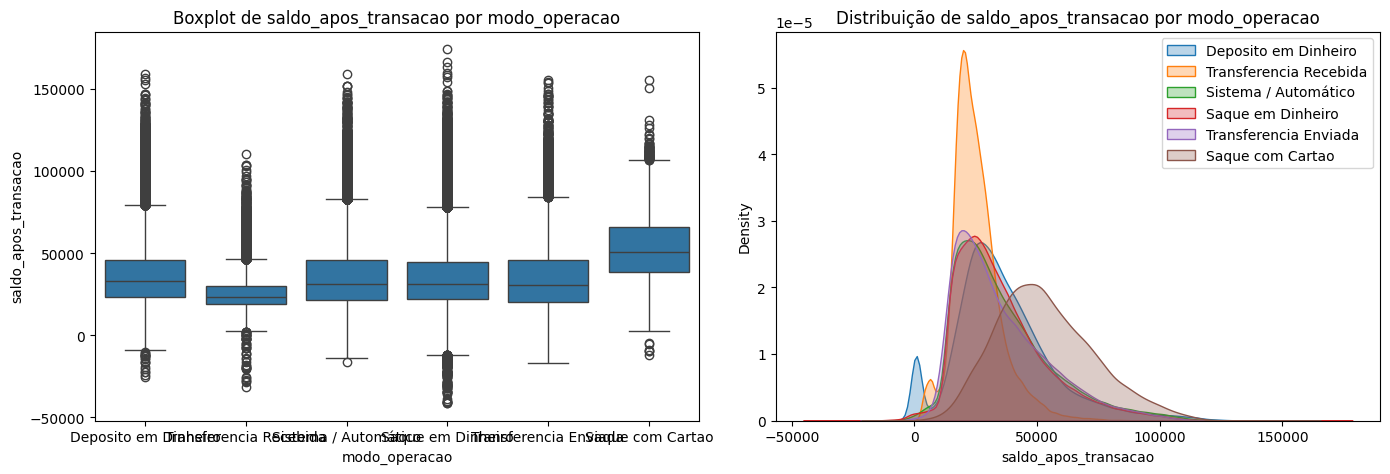

In [100]:
#Aplicação da função

comparar_variavel(df_varejo, var_quantitativa = 'saldo_apos_transacao', var_categorica='modo_operacao')